# ERA5 Time-Series Modellering en Risicoclassificatie
## Droogte- en Overstromingsrisico 2000–2025

Dit notebook modelleert vier klimaatindices afkomstig uit de ERA5-dataset
(periode 2000–2025, locatie 42,75°O / 9,25°N, Hoorn van Afrika):

| Index | Beschrijving | Risico-doel |
|-------|-------------|-------------|
| **SPEI** | Standardized Precipitation-Evapotranspiration Index | Droogte |
| **API** | Antecedent Precipitation Index | Droogte |
| **SMI** | Soil Moisture Index | Overstroming |
| **Total Runoff** | Totale afvoer (m/dag) | Overstroming |

**Aanpak**: drie tijdreeksmodellen worden gefit, vergeleken en ingezet om
toekomstige waarden te voorspellen.  Op basis van de voorspellingen worden
risicoscores berekend met de klassen:
*Laag*, *Gemiddeld*, *Verhoogd*, *Hoog*, *Extreem*.


In [1]:
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.patches import Patch
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

# Voeg de projectroot toe aan het pad zodat src-modules importeerbaar zijn
sys.path.insert(0, "..")

from src.modeling import (
    TimeSeriesPreprocessor,
    check_stationarity,
    SARIMAForecaster,
    HoltWintersForecaster,
    RandomForestForecaster,
    DroughtRiskClassifier,
    FloodRiskClassifier,
    RiskLevel,
)

# ─── Plot-stijl ────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 13})

RISK_COLORS = {
    RiskLevel.LOW:      "#2ecc71",
    RiskLevel.MODERATE: "#f1c40f",
    RiskLevel.ELEVATED: "#e67e22",
    RiskLevel.HIGH:     "#e74c3c",
    RiskLevel.EXTREME:  "#8e44ad",
}
RISK_LEGEND = [Patch(color=c, label=r.value) for r, c in RISK_COLORS.items()]

DATA_PATH = "../src/data/processed/era5_2000_2025.parquet"
TEST_START = "2023-01-01"
FORECAST_MONTHS = 18  # horizon voor toekomstscenario


## 1 · Data laden en verkennen

In [2]:
# ── Maandelijkse aggregatie voor SARIMA en Holt-Winters ────────────────────
prep_m = TimeSeriesPreprocessor(DATA_PATH, resample_freq="ME").load()
df_m = prep_m.df

# ── Dagelijkse data voor Random Forest en risicoclassificatie ──────────────
prep_d = TimeSeriesPreprocessor(DATA_PATH, resample_freq=None).load()
df_d = prep_d.df

print(f"Maandelijks: {df_m.shape[0]} rijen  ({df_m.index[0].date()} → {df_m.index[-1].date()})")
print(f"Dagelijks  : {df_d.shape[0]} rijen  ({df_d.index[0].date()} → {df_d.index[-1].date()})")
df_m[["spei", "api", "smi", "total_ro"]].describe().round(4)


Maandelijks: 312 rijen  (2000-01-31 → 2025-12-31)
Dagelijks  : 9497 rijen  (2000-01-01 → 2025-12-31)


,spei,api,smi,total_ro
count,312.0000,312.0000,312.0000,312.0000
mean,-0.0604,0.0011,0.2824,0.0003
std,0.9274,0.0012,0.1572,0.0005
min,-3.0200,0.0000,0.0241,0.0000
25%,-0.6997,0.0001,0.1295,0.0000
50%,0.1093,0.0007,0.2840,0.0001
75%,0.6104,0.0017,0.3826,0.0002
max,1.8277,0.0065,0.7930,0.0035


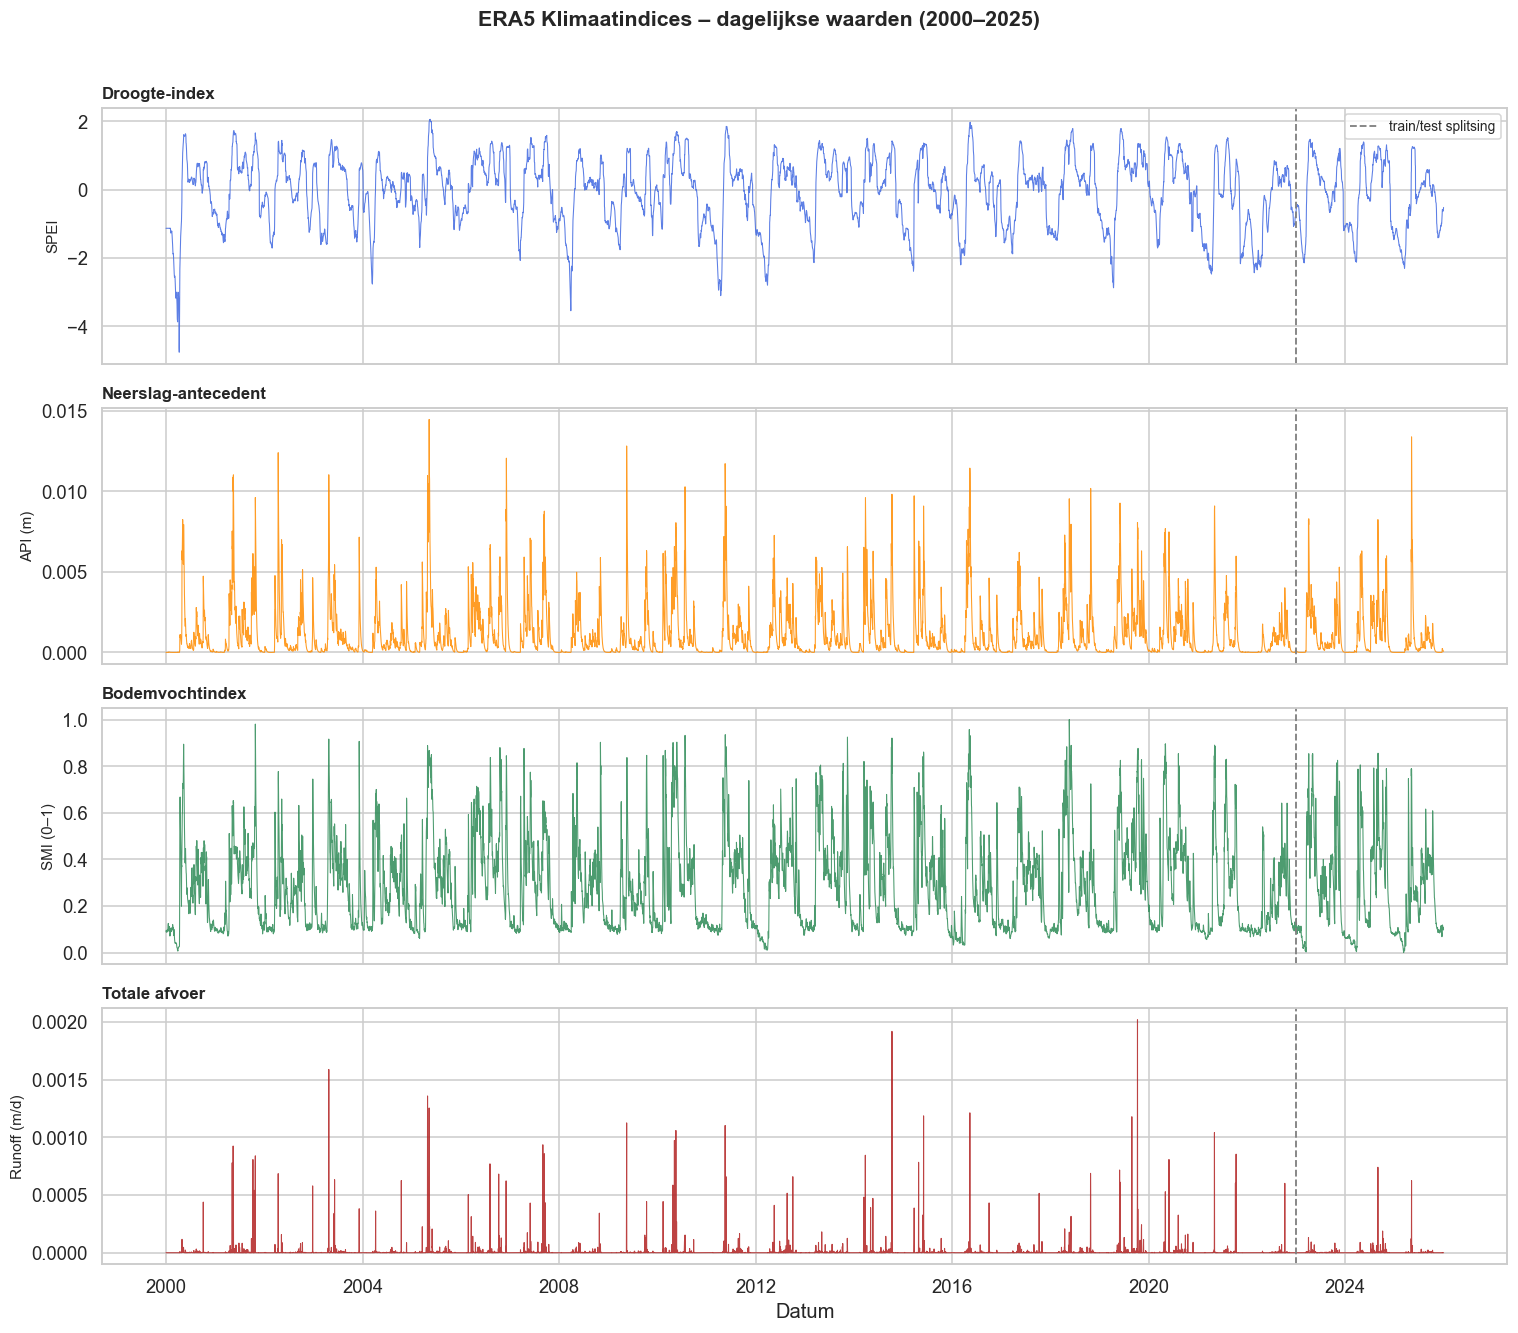

In [3]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
pairs = [
    ("spei",     "SPEI",         "royalblue",  "Droogte-index"),
    ("api",      "API (m)",      "darkorange",  "Neerslag-antecedent"),
    ("smi",      "SMI (0–1)",    "seagreen",    "Bodemvochtindex"),
    ("total_ro", "Runoff (m/d)", "firebrick",   "Totale afvoer"),
]
for ax, (col, ylabel, color, title) in zip(axes, pairs):
    ax.plot(df_d.index, df_d[col], lw=0.7, color=color, alpha=0.85)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11, loc="left", fontweight="bold")
    ax.axvline(pd.Timestamp(TEST_START), color="grey", ls="--", lw=1.2,
               label="train/test splitsing")

axes[0].legend(loc="upper right", fontsize=9)
axes[-1].set_xlabel("Datum")
fig.suptitle("ERA5 Klimaatindices – dagelijkse waarden (2000–2025)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("overzicht_tijdreeksen.png", bbox_inches="tight")
plt.show()


## 2 · Stationariteitsanalyse (ADF-test)

Een tijdreeks is *stationair* als gemiddelde en variantie niet veranderen
over de tijd.  De **Augmented Dickey-Fuller (ADF)** test toetst de
nulhypothese H₀: *de reeks bevat een eenheidswortel (non-stationair)*.
Een p-waarde < 0,05 verwerpt H₀ → stationair.

SARIMA en Holt-Winters kunnen omgaan met niet-stationariteit via de
differentiatieparameter `d` (of `D` voor de seizoenscomponent).


In [4]:
TARGET_COLS = ["spei", "api", "smi", "total_ro"]

rows = []
for col in TARGET_COLS:
    res = check_stationarity(df_m[col])
    rows.append({
        "Index": col.upper(),
        "ADF-statistiek": round(res.statistic, 3),
        "p-waarde": round(res.p_value, 4),
        "Stationair (α=0.05)": "✔ Ja" if res.is_stationary else "✘ Nee",
        "Kritieke waarde 5%": round(res.critical_values["5%"], 3),
    })

pd.DataFrame(rows).set_index("Index")


,ADF-statistiek,p-waarde,Stationair (α=0.05),Kritieke waarde 5%
Index,,,,
SPEI,-3.489,0.0083,✔ Ja,-2.871
API,-3.897,0.0021,✔ Ja,-2.871
SMI,-3.409,0.0106,✔ Ja,-2.871
TOTAL_RO,-4.484,0.0002,✔ Ja,-2.871


## 3 · Seizoensanalyse – ACF en PACF

De **Autocorrelatiefunctie (ACF)** toont de correlatie van de reeks met
zichzelf bij verschillende lags.  De **Partiële ACF (PACF)** corrigeert
voor tussenliggende lags.  Pieken bij lag 12 (maanden) bevestigen een
jaarlijkse seizoenscyclus.


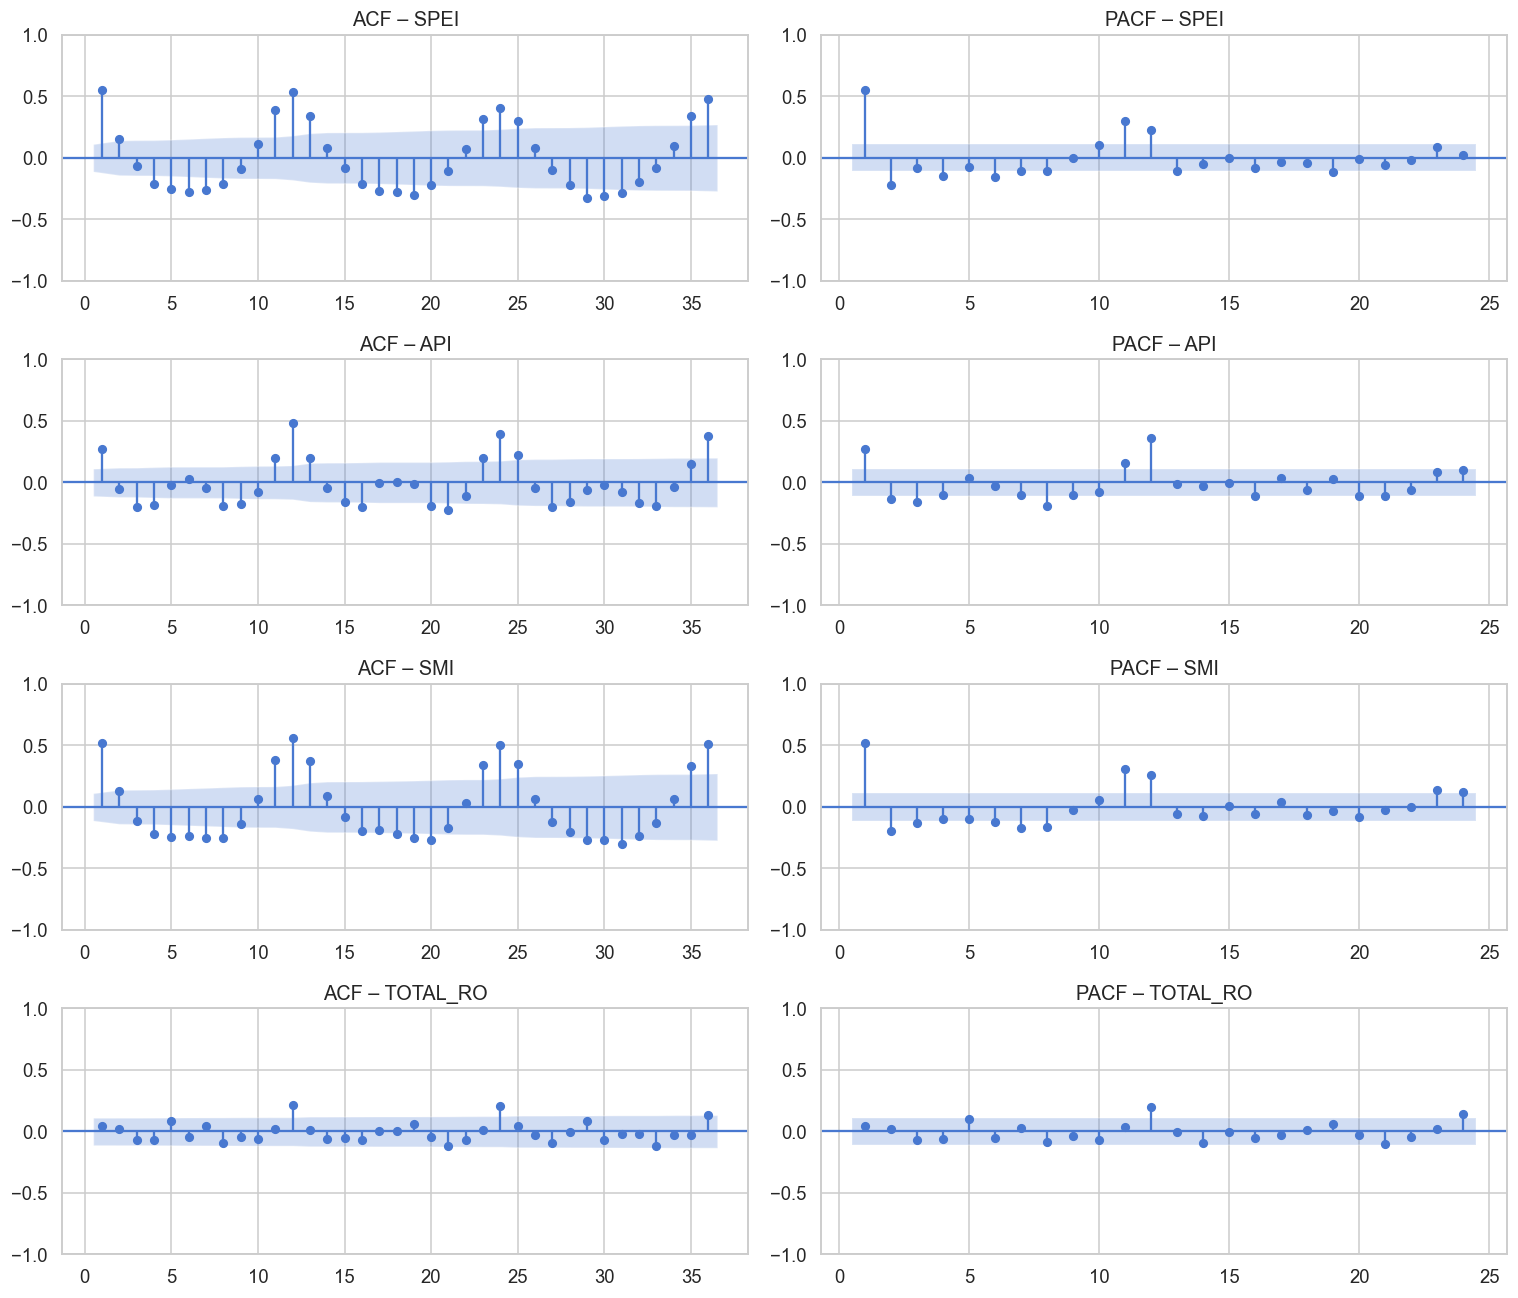

In [5]:
fig, axes = plt.subplots(4, 2, figsize=(14, 12))

for i, col in enumerate(TARGET_COLS):
    series = df_m[col].dropna()
    plot_acf(series, lags=36, ax=axes[i, 0],
             title=f"ACF – {col.upper()}", zero=False)
    plot_pacf(series, lags=24, ax=axes[i, 1],
              title=f"PACF – {col.upper()}", zero=False, method="ywm")

plt.tight_layout()
plt.savefig("acf_pacf.png", bbox_inches="tight")
plt.show()


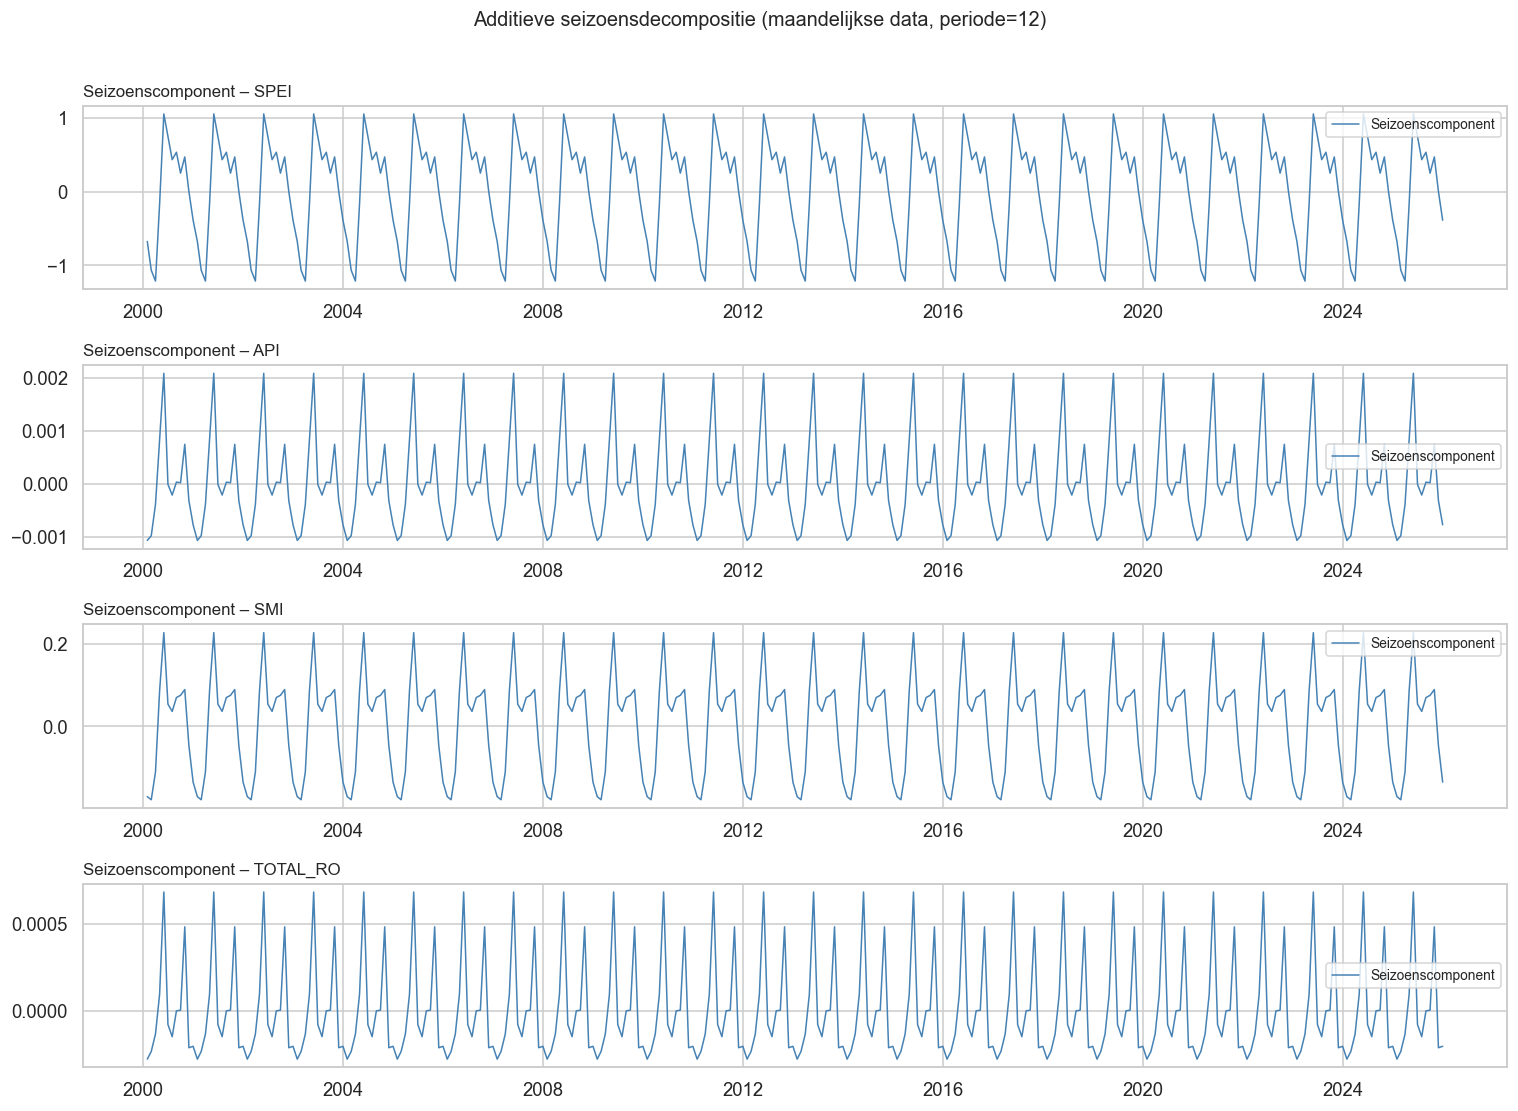

In [6]:
fig, axes = plt.subplots(4, 1, figsize=(14, 10))
for ax, col in zip(axes, TARGET_COLS):
    series = df_m[col].dropna()
    result = seasonal_decompose(series, model="additive", period=12)
    ax.plot(result.seasonal, lw=1, color="steelblue", label="Seizoenscomponent")
    ax.set_title(f"Seizoenscomponent – {col.upper()}", fontsize=11, loc="left")
    ax.set_xlabel("")
    ax.legend(fontsize=9)

plt.suptitle("Additieve seizoensdecompositie (maandelijkse data, periode=12)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("seizoensdecompositie.png", bbox_inches="tight")
plt.show()


## 4 · Train/test splitsing

In [7]:
train_m, test_m = prep_m.train_test_split(TEST_START)
train_d, test_d = prep_d.train_test_split(TEST_START)

print(f"Maandelijks – train: {len(train_m)} | test: {len(test_m)}")
print(f"Dagelijks  – train: {len(train_d)} | test: {len(test_d)}")


Maandelijks – train: 276 | test: 36
Dagelijks  – train: 8401 | test: 1096


## 5 · Model 1 – SARIMA

**Seasonal AutoRegressive Integrated Moving Average** (SARIMA) breidt het
klassieke ARIMA-model uit met seizoenscomponenten `(P, D, Q, s)` waarbij
`s=12` voor maandelijkse data.

Gekozen orde per index:

| Index | (p,d,q) | (P,D,Q,s) | Reden |
|-------|---------|-----------|-------|
| SPEI | (1,1,1) | (1,1,1,12) | Niet-stationair, sterke seizoenspieken bij lag 12 |
| API  | (1,0,1) | (1,1,1,12) | Near-stationair maar seizoenspatroon aanwezig |
| SMI  | (1,1,1) | (1,1,1,12) | Niet-stationair, seizoenspatroon |
| Total Runoff | (1,1,0) | (0,1,1,12) | Sterk asymmetrisch, eenvoudige orde |


In [8]:
SARIMA_PARAMS = {
    "spei":     {"order": (1, 1, 1), "seasonal_order": (1, 1, 1, 12)},
    "api":      {"order": (1, 0, 1), "seasonal_order": (1, 1, 1, 12)},
    "smi":      {"order": (1, 1, 1), "seasonal_order": (1, 1, 1, 12)},
    "total_ro": {"order": (1, 1, 0), "seasonal_order": (0, 1, 1, 12)},
}

sarima_models = {}
sarima_metrics = {}

for col, params in SARIMA_PARAMS.items():
    print(f"  Fitten SARIMA voor {col.upper()} ...", end=" ")
    model = SARIMAForecaster(target_column=col, **params)
    model.fit(train_m[col])
    pred = model.predict_in_sample(test_m[col])
    metrics = model.evaluate(test_m[col], pred)
    sarima_models[col] = model
    sarima_metrics[col] = metrics
    print(f"RMSE={metrics.rmse:.4f}  MAE={metrics.mae:.4f}  R²={metrics.r2:.3f}")


  Fitten SARIMA voor SPEI ... RMSE=0.5944  MAE=0.4655  R²=0.593
  Fitten SARIMA voor API ... RMSE=0.0008  MAE=0.0006  R²=0.395
  Fitten SARIMA voor SMI ... RMSE=0.1033  MAE=0.0842  R²=0.601
  Fitten SARIMA voor TOTAL_RO ... RMSE=0.0003  MAE=0.0002  R²=-0.996


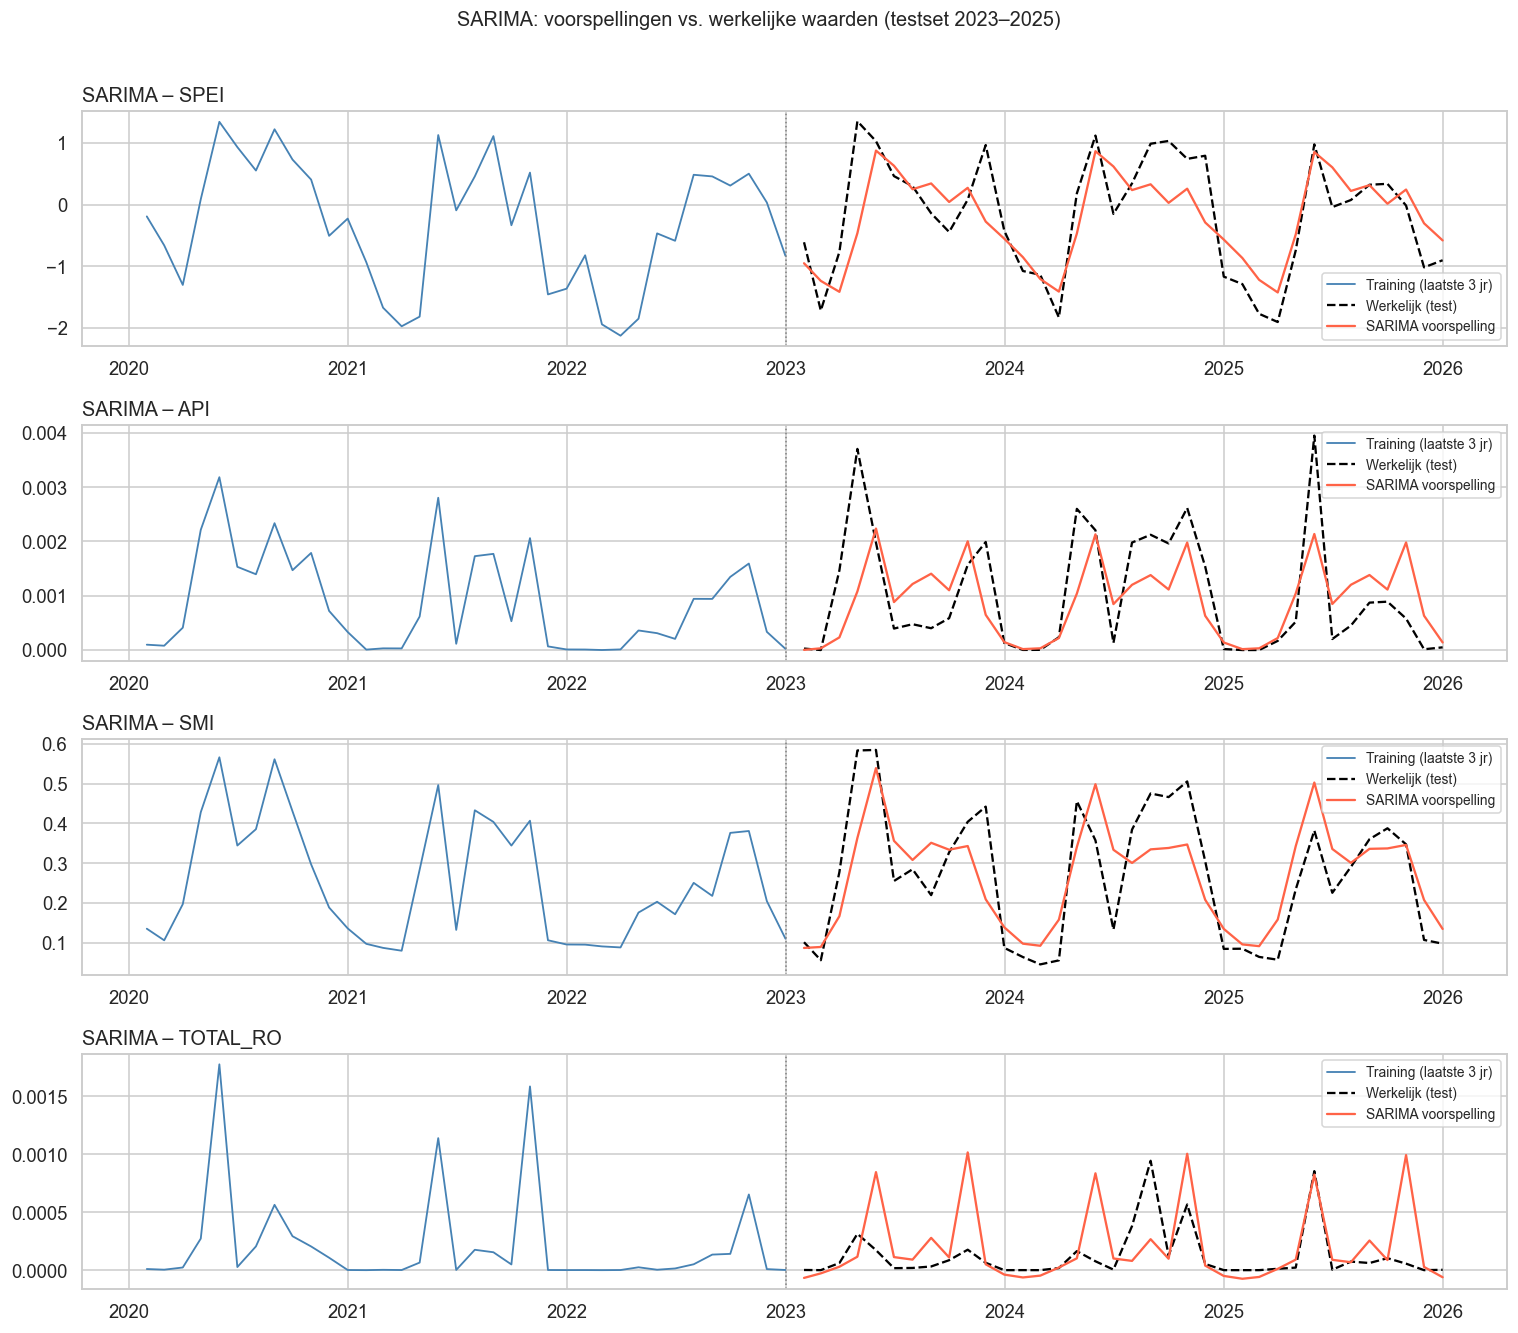

In [9]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=False)
for ax, col in zip(axes, TARGET_COLS):
    model = sarima_models[col]
    pred  = model.predict_in_sample(test_m[col])
    ax.plot(train_m.index[-36:], train_m[col].iloc[-36:],
            color="steelblue", lw=1.2, label="Training (laatste 3 jr)")
    ax.plot(test_m.index, test_m[col],
            color="black", lw=1.5, ls="--", label="Werkelijk (test)")
    ax.plot(test_m.index, pred,
            color="tomato", lw=1.5, label="SARIMA voorspelling")
    ax.axvline(pd.Timestamp(TEST_START), color="grey", ls=":", lw=1)
    ax.set_title(f"SARIMA – {col.upper()}", loc="left")
    ax.legend(fontsize=9)

plt.suptitle("SARIMA: voorspellingen vs. werkelijke waarden (testset 2023–2025)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("sarima_resultaten.png", bbox_inches="tight")
plt.show()


## 6 · Model 2 – Holt-Winters (Triple Exponential Smoothing)

Holt-Winters past drie exponentiële afvlakkingen toe voor niveau, trend
en seizoen.  Het model is robuust bij kortere reeksen en vereist geen
stationariteit.  Voor `total_ro` wordt een additief seizoen gebruikt
omdat de reeks nul-inflatie heeft en geen negatieve waarden kent.


In [10]:
hw_models = {}
hw_metrics = {}

for col in TARGET_COLS:
    print(f"  Fitten HoltWinters voor {col.upper()} ...", end=" ")
    model = HoltWintersForecaster(
        target_column=col,
        seasonal_periods=12,
        trend="add",
        seasonal="add",
    )
    model.fit(train_m[col])
    pred = model.predict_in_sample(test_m[col])
    metrics = model.evaluate(test_m[col], pred)
    hw_models[col] = model
    hw_metrics[col] = metrics
    print(f"RMSE={metrics.rmse:.4f}  MAE={metrics.mae:.4f}  R²={metrics.r2:.3f}")


  Fitten HoltWinters voor SPEI ... RMSE=0.6107  MAE=0.4680  R²=0.570
  Fitten HoltWinters voor API ... RMSE=0.0008  MAE=0.0006  R²=0.481
  Fitten HoltWinters voor SMI ... RMSE=0.1133  MAE=0.0861  R²=0.520
  Fitten HoltWinters voor TOTAL_RO ... RMSE=0.0003  MAE=0.0002  R²=-1.021


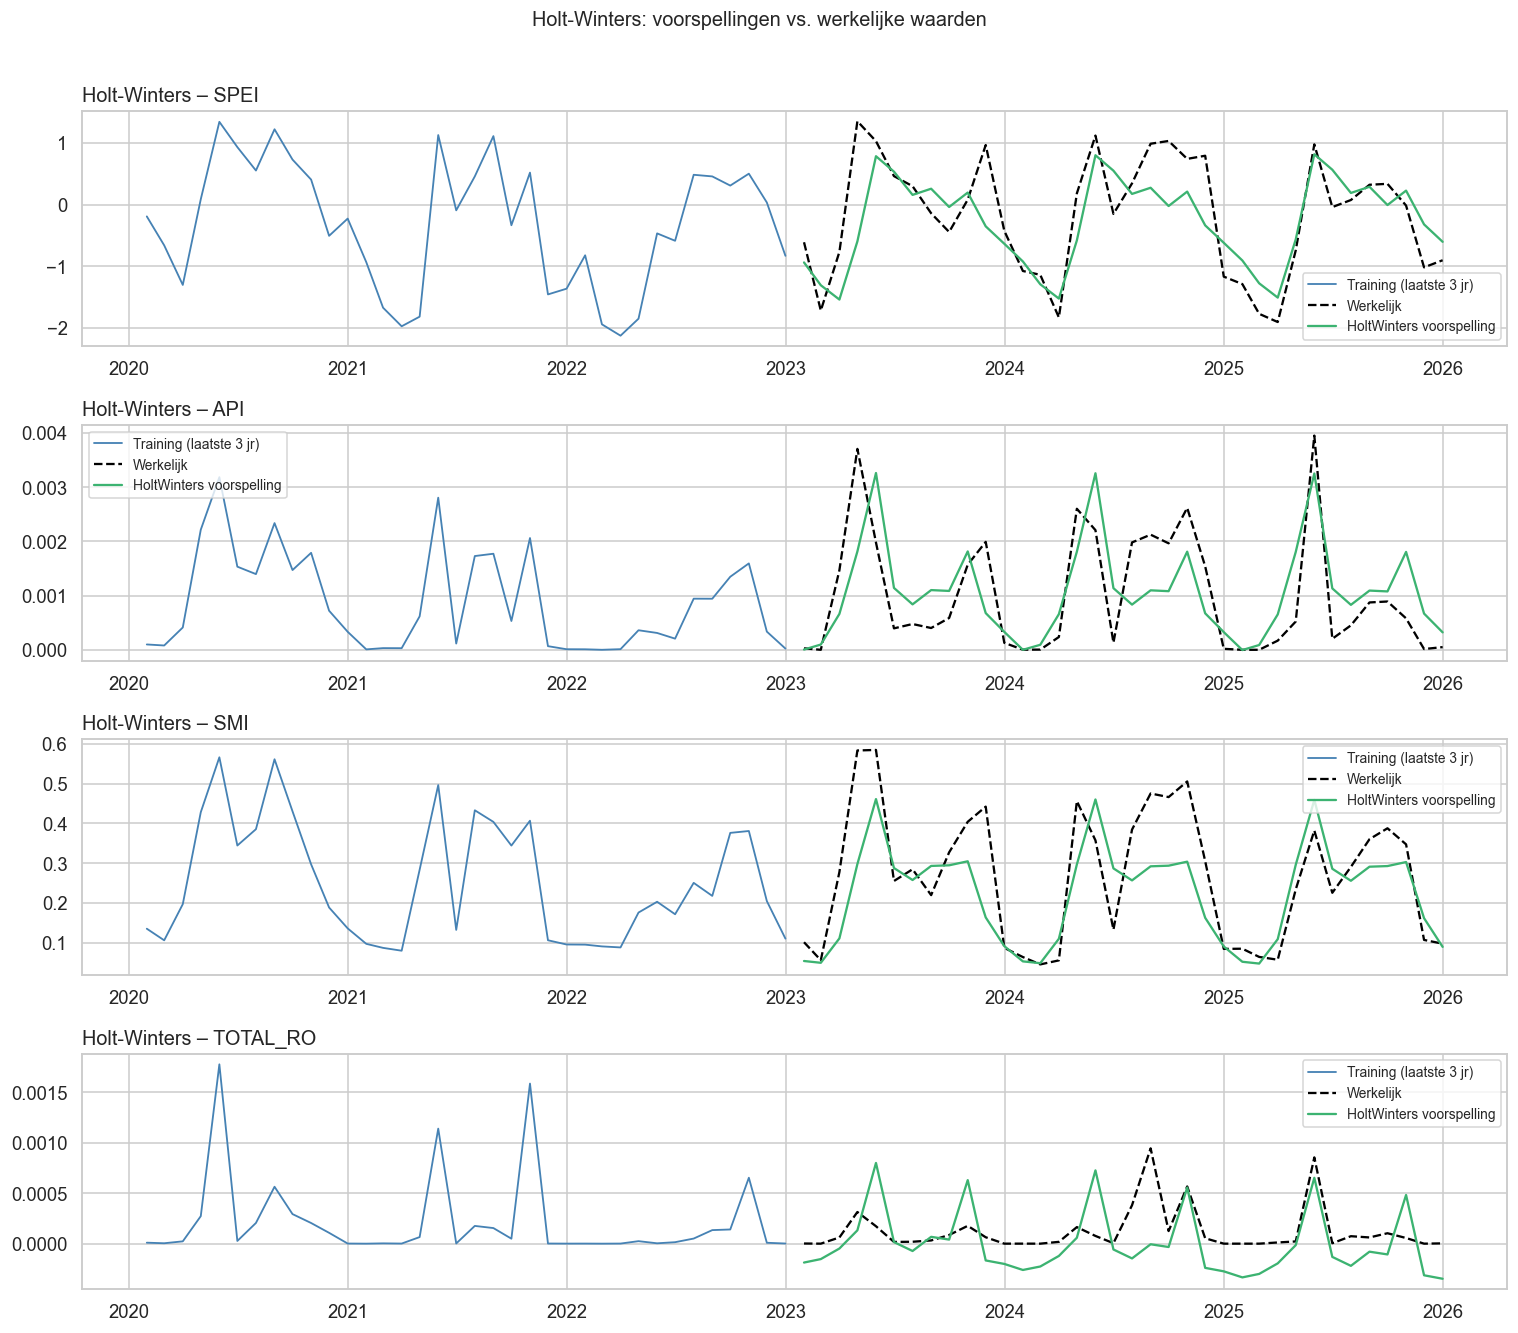

In [11]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=False)
for ax, col in zip(axes, TARGET_COLS):
    model = hw_models[col]
    pred  = model.predict_in_sample(test_m[col])
    ax.plot(train_m.index[-36:], train_m[col].iloc[-36:],
            color="steelblue", lw=1.2, label="Training (laatste 3 jr)")
    ax.plot(test_m.index, test_m[col],
            color="black", lw=1.5, ls="--", label="Werkelijk")
    ax.plot(test_m.index, pred,
            color="mediumseagreen", lw=1.5, label="HoltWinters voorspelling")
    ax.set_title(f"Holt-Winters – {col.upper()}", loc="left")
    ax.legend(fontsize=9)

plt.suptitle("Holt-Winters: voorspellingen vs. werkelijke waarden",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("holtwinters_resultaten.png", bbox_inches="tight")
plt.show()


## 7 · Model 3 – Random Forest (maandelijks, lag-features)

Random Forest transformeert het voorspelprobleem naar gesuperviseerde
regressie door de tijdreeks te voorzien van *lag-features* (vertraagde
waarden) en *cyclische seizoensencoderingen* (sinus/cosinus van maand en
dag-van-het-jaar).  Dit maakt het model niet-parametrisch en robuust
voor niet-lineaire patronen.

Lags gebruikt: `[1, 2, 3, 6, 12]` maanden.


In [12]:
rf_models = {}
rf_metrics = {}

for col in TARGET_COLS:
    print(f"  Fitten RandomForest voor {col.upper()} ...", end=" ")
    model = RandomForestForecaster(
        target_column=col,
        lags=[1, 2, 3, 6, 12],
        n_estimators=200,
        random_state=42,
    )
    model.fit(train_m[col])
    pred = model.predict_in_sample(test_m[col])
    metrics = model.evaluate(test_m[col], pred)
    rf_models[col] = model
    rf_metrics[col] = metrics
    print(f"RMSE={metrics.rmse:.4f}  MAE={metrics.mae:.4f}  R²={metrics.r2:.3f}")


  Fitten RandomForest voor SPEI ... RMSE=0.5960  MAE=0.4740  R²=0.590
  Fitten RandomForest voor API ... RMSE=0.0007  MAE=0.0006  R²=0.569
  Fitten RandomForest voor SMI ... RMSE=0.0896  MAE=0.0762  R²=0.700
  Fitten RandomForest voor TOTAL_RO ... RMSE=0.0003  MAE=0.0002  R²=-0.823


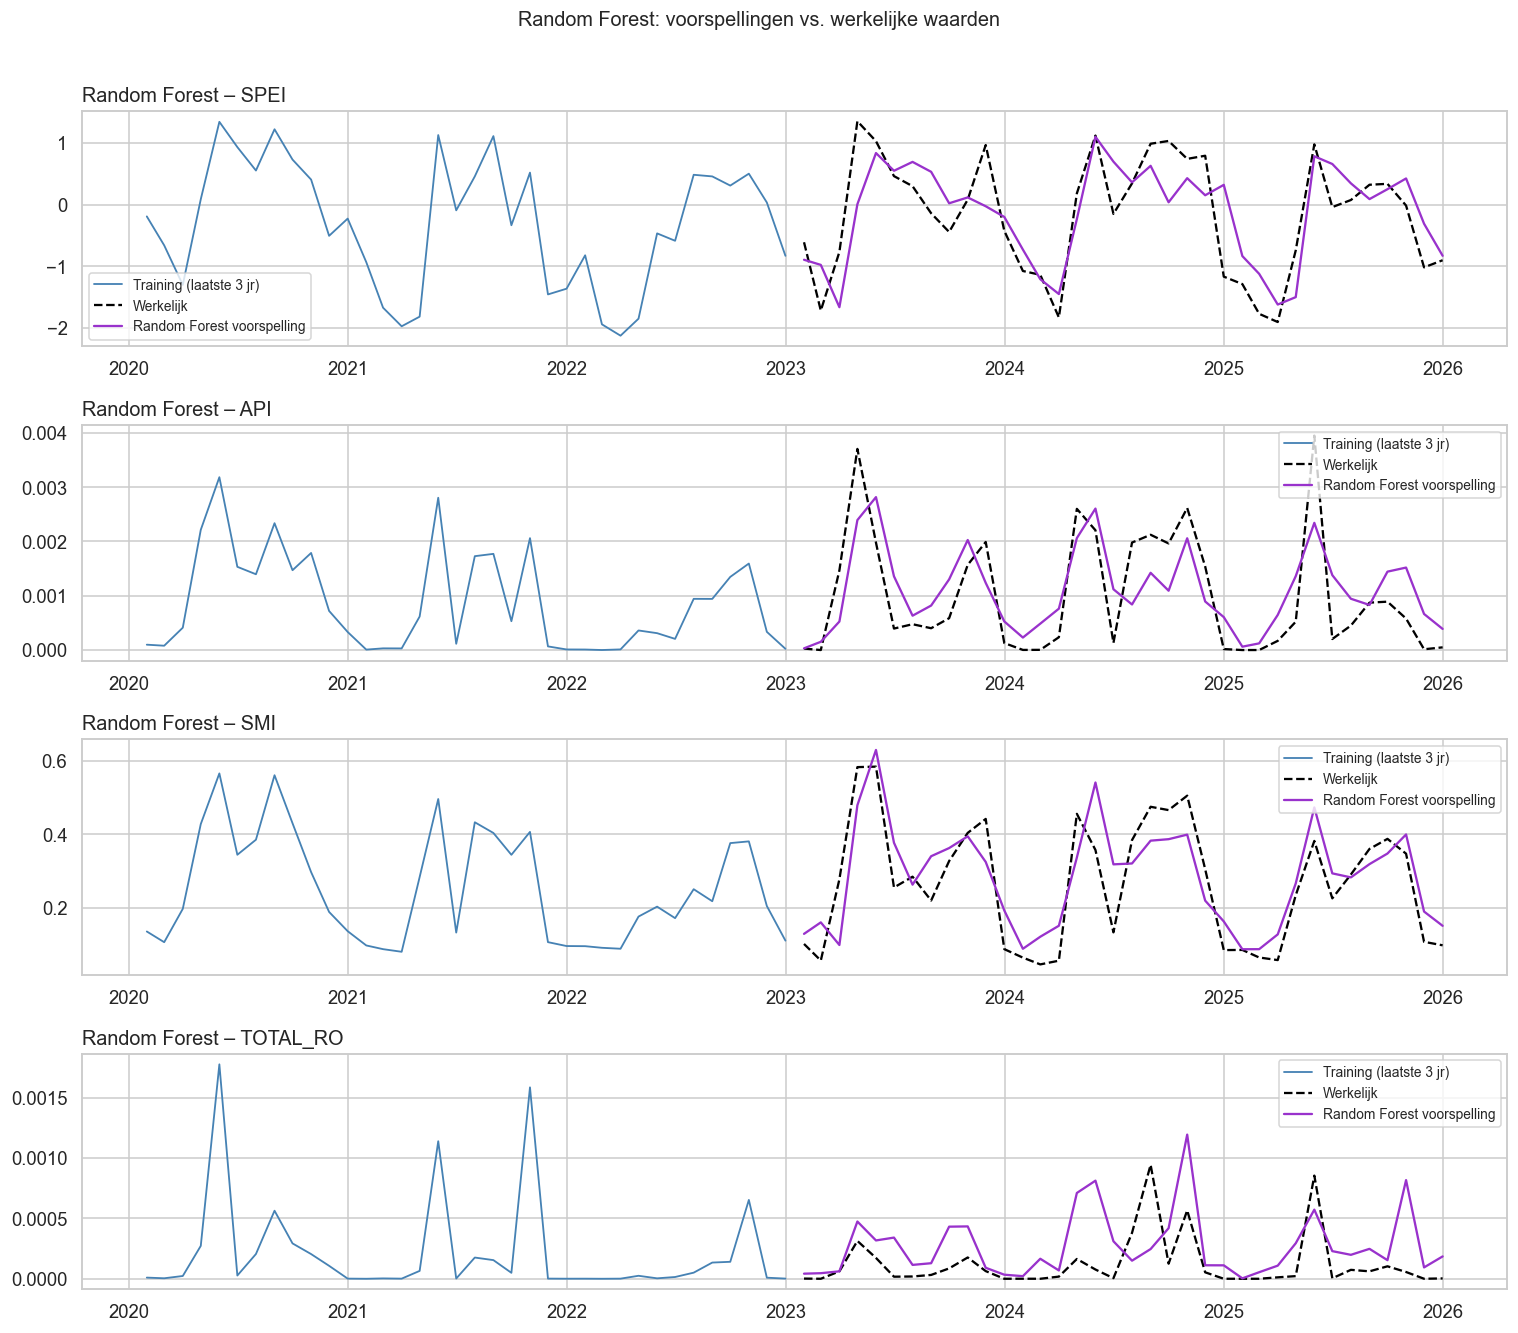

In [13]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=False)
for ax, col in zip(axes, TARGET_COLS):
    model = rf_models[col]
    pred  = model.predict_in_sample(test_m[col])
    ax.plot(train_m.index[-36:], train_m[col].iloc[-36:],
            color="steelblue", lw=1.2, label="Training (laatste 3 jr)")
    ax.plot(test_m.index, test_m[col],
            color="black", lw=1.5, ls="--", label="Werkelijk")
    ax.plot(test_m.index, pred,
            color="darkorchid", lw=1.5, label="Random Forest voorspelling")
    ax.set_title(f"Random Forest – {col.upper()}", loc="left")
    ax.legend(fontsize=9)

plt.suptitle("Random Forest: voorspellingen vs. werkelijke waarden",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("rf_resultaten.png", bbox_inches="tight")
plt.show()


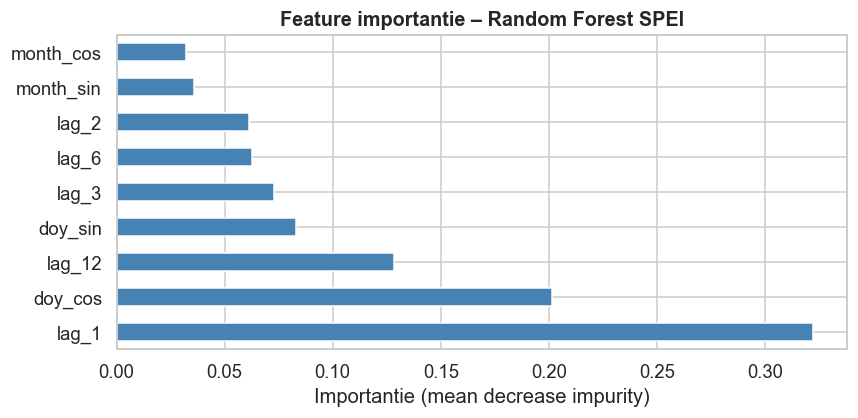

In [14]:
# Feature-importantie voor SPEI (representatief voorbeeld)
fi = rf_models["spei"].feature_importances
fig, ax = plt.subplots(figsize=(8, 4))
fi.plot.barh(ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Feature importantie – Random Forest SPEI", fontweight="bold")
ax.set_xlabel("Importantie (mean decrease impurity)")
plt.tight_layout()
plt.savefig("rf_feature_importance.png", bbox_inches="tight")
plt.show()


## 8 · Modelcomparisatie

In [15]:
rows = []
for col in TARGET_COLS:
    for model_name, metrics_dict in [
        ("SARIMA",       sarima_metrics),
        ("Holt-Winters", hw_metrics),
        ("RandomForest", rf_metrics),
    ]:
        m = metrics_dict[col]
        rows.append({
            "Index": col.upper(),
            "Model": model_name,
            "RMSE": round(m.rmse, 5),
            "MAE":  round(m.mae, 5),
            "R²":   round(m.r2, 3),
        })

comparison_df = pd.DataFrame(rows).set_index(["Index", "Model"])
comparison_df.style.highlight_min(subset=["RMSE", "MAE"], color="lightgreen") \
                   .highlight_max(subset=["R²"],           color="lightgreen")


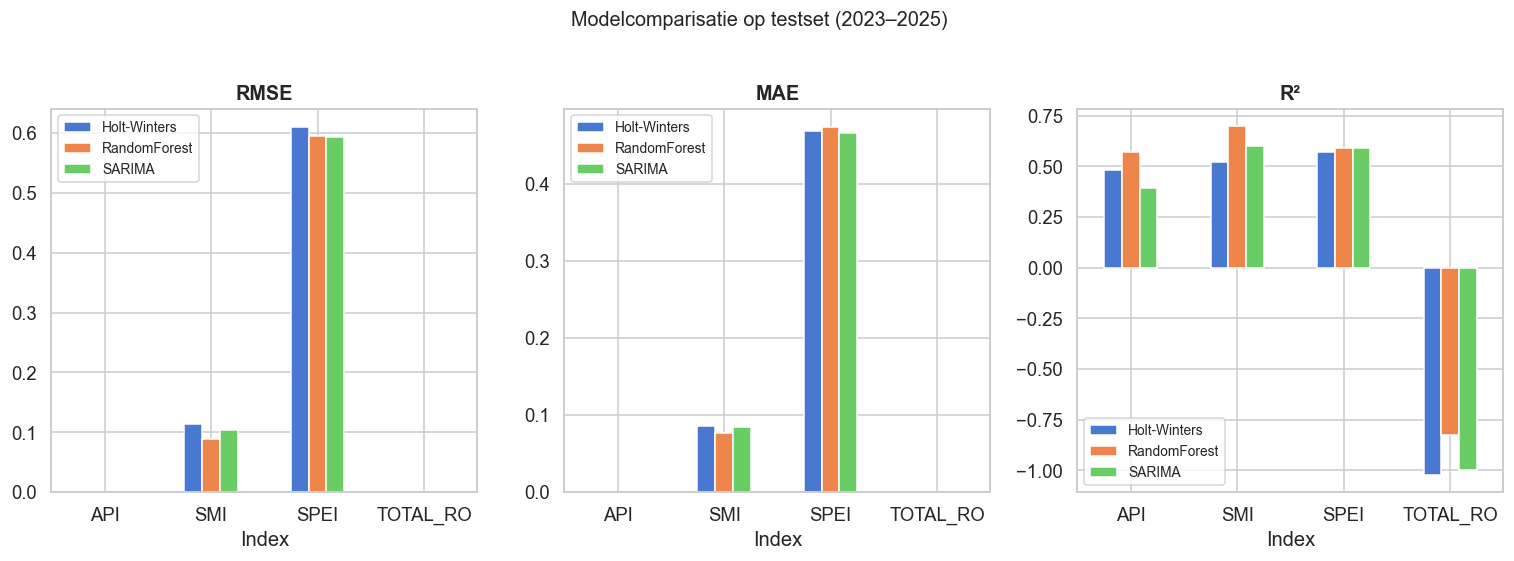

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, metric in zip(axes, ["RMSE", "MAE", "R²"]):
    pivot = comparison_df[metric].unstack("Model")
    pivot.plot.bar(ax=ax, edgecolor="white")
    ax.set_title(metric, fontweight="bold")
    ax.set_xlabel("Index")
    ax.legend(fontsize=9)
    ax.tick_params(axis="x", rotation=0)

plt.suptitle("Modelcomparisatie op testset (2023–2025)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("model_vergelijking.png", bbox_inches="tight")
plt.show()


In [17]:
# Selecteer het beste model per index op basis van RMSE
best_models = {}
for col in TARGET_COLS:
    col_df = comparison_df.loc[col.upper(), "RMSE"]
    best_name = col_df.idxmin()
    print(f"{col.upper():12s} → beste model: {best_name}  "
          f"(RMSE={col_df[best_name]:.5f})")
    if best_name == "SARIMA":
        best_models[col] = sarima_models[col]
    elif best_name == "Holt-Winters":
        best_models[col] = hw_models[col]
    else:
        best_models[col] = rf_models[col]


SPEI         → beste model: SARIMA  (RMSE=0.59444)
API          → beste model: RandomForest  (RMSE=0.00072)
SMI          → beste model: RandomForest  (RMSE=0.08957)
TOTAL_RO     → beste model: RandomForest  (RMSE=0.00030)


## 9 · Droogterisicoclassificatie

De `DroughtRiskClassifier` combineert SPEI en API:

1. **SPEI** (primair) – geclassificeerd conform McKee et al. (1993):
   - ≥ −0,5 → *Laag*  | −1,0 tot −0,5 → *Gemiddeld*
   - −1,5 tot −1,0 → *Verhoogd* | −2,0 tot −1,5 → *Hoog* | < −2,0 → *Extreem*
2. **API** (modificator) – als API < 25e percentiel (kwartiel) wordt
   het risiconiveau één klasse verhoogd.


In [18]:
drought_clf = DroughtRiskClassifier(api_low_percentile=0.25)
drought_clf.fit(train_d)

# Classificeer de volledige dagelijkse reeks
drought_risk_daily = drought_clf.classify(df_d)

# Overzicht per risicoklasse
counts = drought_risk_daily.value_counts()
pct    = (counts / len(drought_risk_daily) * 100).round(1)
summary = pd.DataFrame({"Dagen": counts, "%": pct})
summary.index = [r.value for r in summary.index]
print("Droogterisico – verdeling over volledige periode:")
summary


Droogterisico – verdeling over volledige periode:


,Dagen,%
Laag risico,6243,65.7
Verhoogd risico,904,9.5
Hoog risico,895,9.4
Gemiddeld risico,729,7.7
Extreem risico,726,7.6


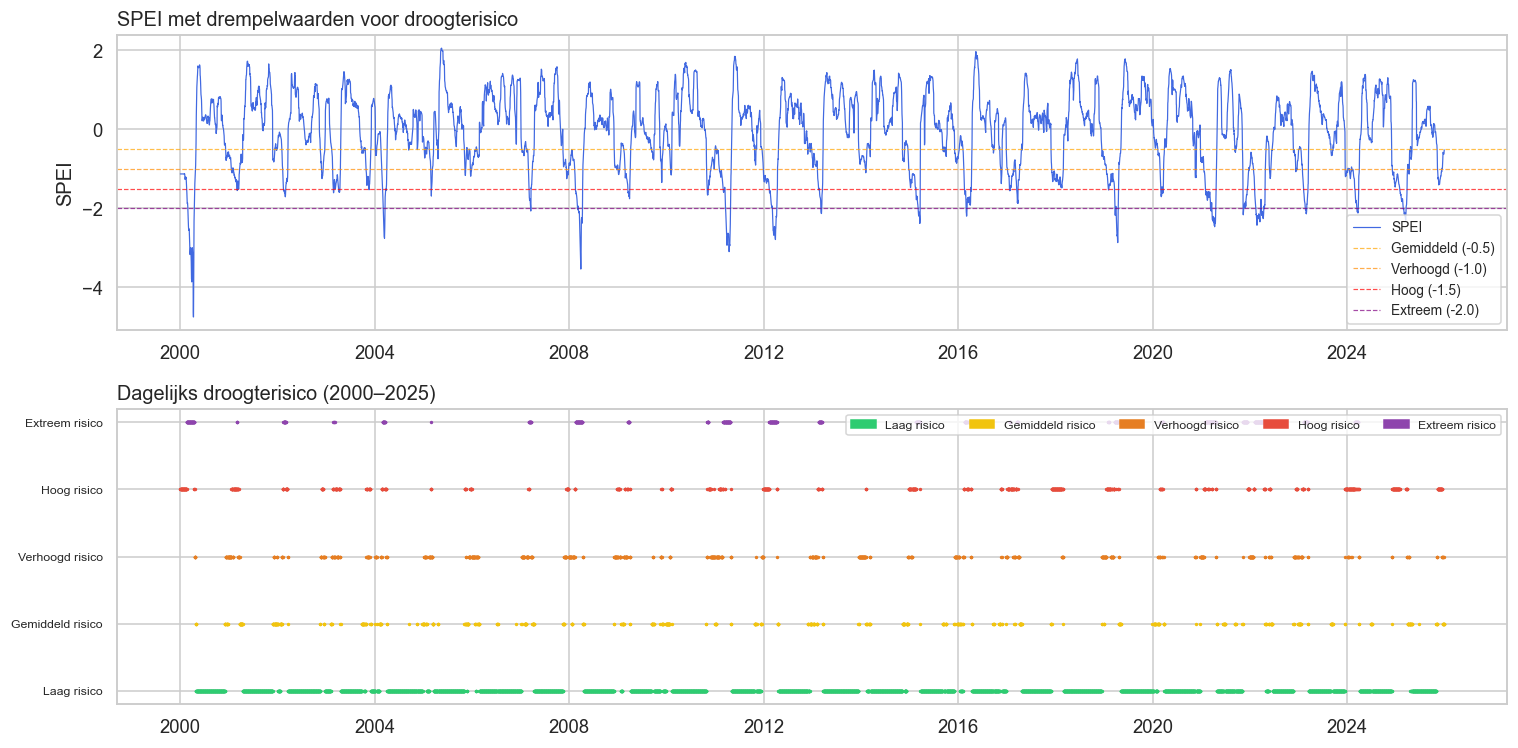

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# Tijdreeks met achtergrondkleuren
ax = axes[0]
ax.plot(df_d.index, df_d["spei"], lw=0.8, color="royalblue", label="SPEI")
ax.axhline(-0.5, color="orange",  ls="--", lw=0.8, alpha=0.7)
ax.axhline(-1.0, color="darkorange", ls="--", lw=0.8, alpha=0.7)
ax.axhline(-1.5, color="red", ls="--", lw=0.8, alpha=0.7)
ax.axhline(-2.0, color="purple", ls="--", lw=0.8, alpha=0.7)
ax.set_ylabel("SPEI")
ax.set_title("SPEI met drempelwaarden voor droogterisico", loc="left")
ax.legend(["SPEI", "Gemiddeld (-0.5)", "Verhoogd (-1.0)",
           "Hoog (-1.5)", "Extreem (-2.0)"], fontsize=9)

# Risico als numerieke tijdreeks
ax2 = axes[1]
risk_numeric = drought_risk_daily.apply(lambda r: r.numeric)
# Kleur elk punt op basis van risiconiveau
for level in RiskLevel:
    mask = drought_risk_daily == level
    ax2.scatter(
        df_d.index[mask], risk_numeric[mask],
        s=1.5, color=RISK_COLORS[level], label=level.value
    )
ax2.set_yticks(range(5))
ax2.set_yticklabels([r.value for r in RiskLevel], fontsize=8)
ax2.set_title("Dagelijks droogterisico (2000–2025)", loc="left")
ax2.legend(handles=RISK_LEGEND, fontsize=8, ncol=5, loc="upper right")

plt.tight_layout()
plt.savefig("droogterisico_historisch.png", bbox_inches="tight")
plt.show()


## 10 · Overstromingsrisicoclassificatie

De `FloodRiskClassifier` combineert SMI en Total Runoff via een gewogen
composietscores:

    flood_score = 0,5 × norm_SMI + 0,5 × norm_total_ro

Beide indicatoren worden Min-Max genormaliseerd op de trainingsdata.
Risicodrempels worden afgeleid van de empirische percentielen van de
composietscores (40e, 60e, 75e, 90e percentielen).

> **Rationale**: een hoge SMI geeft aan dat de bodem verzadigd is
> (weinig absorptiecapaciteit) en hoge runoff geeft direct waterafvoer
> over het maaiveld aan — samen zijn dit de belangrijkste overstromings-
> precursors (Berghuijs et al., 2019).


In [20]:
flood_clf = FloodRiskClassifier(smi_weight=0.5, runoff_weight=0.5)
flood_clf.fit(train_d)

flood_risk_daily = flood_clf.classify(df_d)

counts_f = flood_risk_daily.value_counts()
pct_f    = (counts_f / len(flood_risk_daily) * 100).round(1)
summary_f = pd.DataFrame({"Dagen": counts_f, "%": pct_f})
summary_f.index = [r.value for r in summary_f.index]
print("Overstromingsrisico – verdeling over volledige periode:")
summary_f


Overstromingsrisico – verdeling over volledige periode:


,Dagen,%
Laag risico,3846,40.5
Gemiddeld risico,1870,19.7
Hoog risico,1425,15.0
Verhoogd risico,1402,14.8
Extreem risico,954,10.0


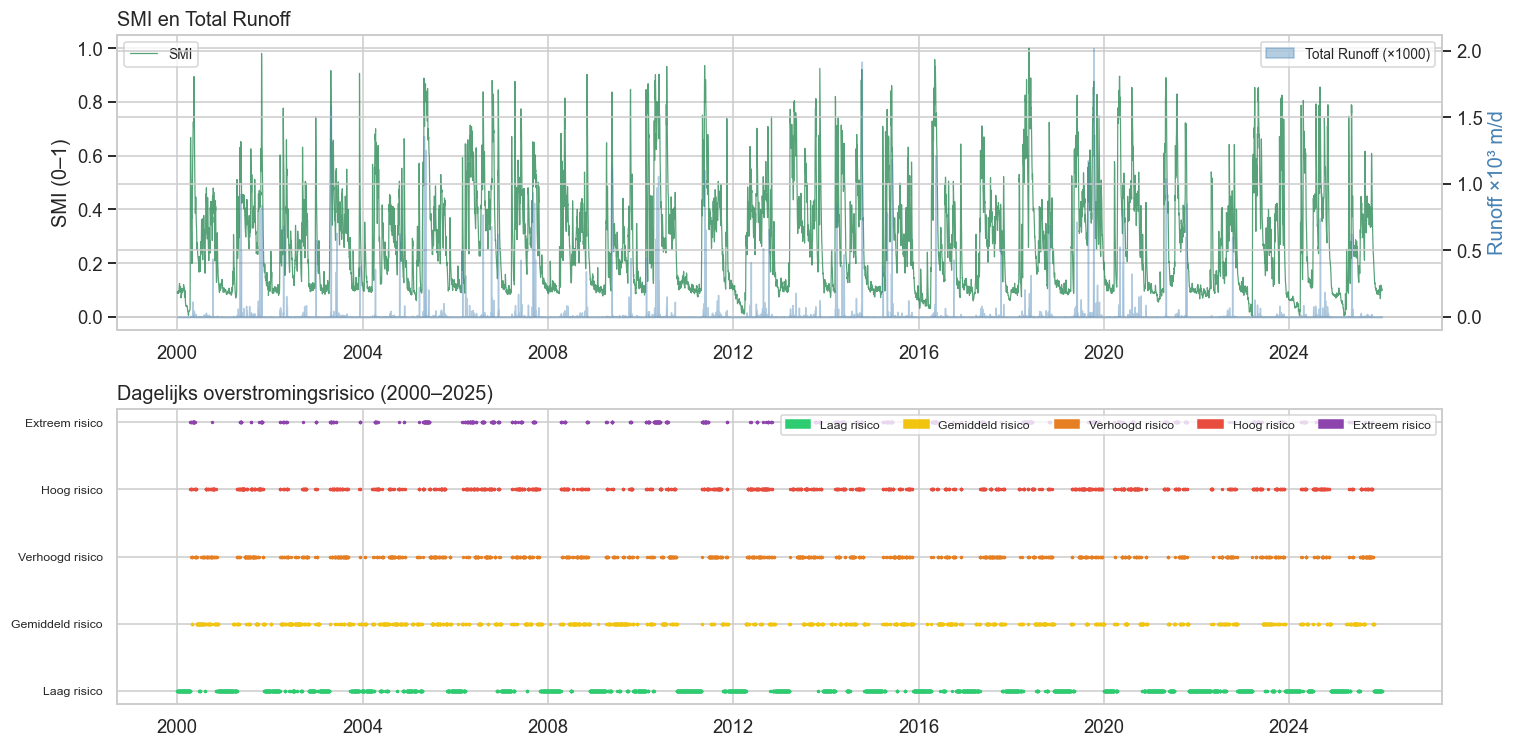

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# SMI tijdreeks
ax = axes[0]
ax.plot(df_d.index, df_d["smi"], lw=0.8, color="seagreen", label="SMI", alpha=0.8)
ax2b = ax.twinx()
ax2b.fill_between(df_d.index, df_d["total_ro"] * 1000, alpha=0.4,
                  color="steelblue", label="Total Runoff (×1000)")
ax2b.set_ylabel("Runoff ×10³ m/d", color="steelblue")
ax.set_ylabel("SMI (0–1)")
ax.set_title("SMI en Total Runoff", loc="left")
ax.legend(loc="upper left", fontsize=9)
ax2b.legend(loc="upper right", fontsize=9)

# Risico
ax3 = axes[1]
risk_numeric_f = flood_risk_daily.apply(lambda r: r.numeric)
for level in RiskLevel:
    mask = flood_risk_daily == level
    ax3.scatter(
        df_d.index[mask], risk_numeric_f[mask],
        s=1.5, color=RISK_COLORS[level], label=level.value
    )
ax3.set_yticks(range(5))
ax3.set_yticklabels([r.value for r in RiskLevel], fontsize=8)
ax3.set_title("Dagelijks overstromingsrisico (2000–2025)", loc="left")
ax3.legend(handles=RISK_LEGEND, fontsize=8, ncol=5, loc="upper right")

plt.tight_layout()
plt.savefig("overstromingsrisico_historisch.png", bbox_inches="tight")
plt.show()


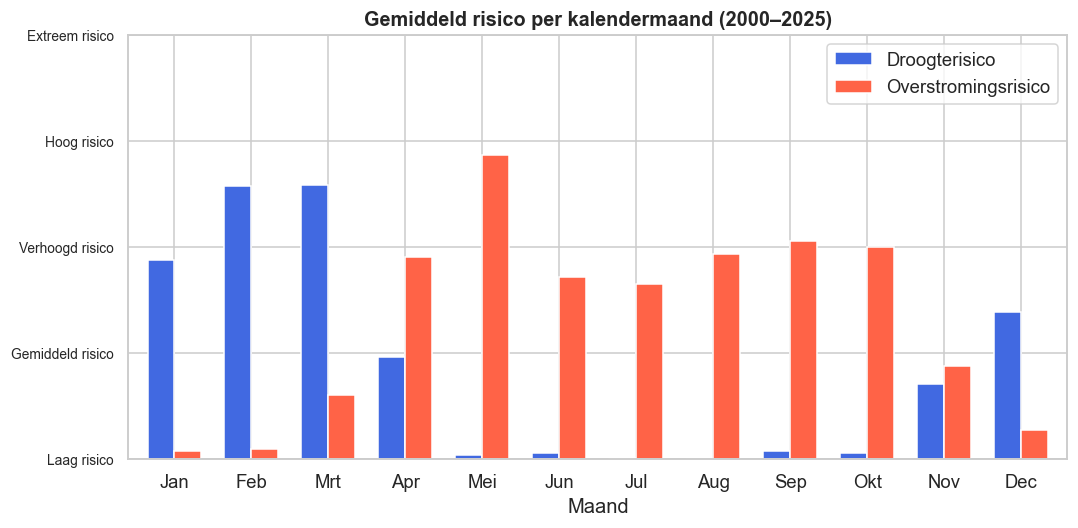

In [22]:
# Gemiddeld risico per maand (numeriek)
df_risk = pd.DataFrame({
    "drought":  drought_risk_daily.apply(lambda r: r.numeric),
    "flood":    flood_risk_daily.apply(lambda r: r.numeric),
    "month":    df_d.index.month,
})
monthly_risk = df_risk.groupby("month")[["drought", "flood"]].mean()
monthly_risk.index = ["Jan","Feb","Mrt","Apr","Mei","Jun",
                       "Jul","Aug","Sep","Okt","Nov","Dec"]

fig, ax = plt.subplots(figsize=(10, 5))
monthly_risk.plot.bar(ax=ax, color=["royalblue", "tomato"],
                      edgecolor="white", width=0.7)
ax.set_yticks(range(5))
ax.set_yticklabels([r.value for r in RiskLevel], fontsize=9)
ax.set_xlabel("Maand")
ax.set_title("Gemiddeld risico per kalendermaand (2000–2025)", fontweight="bold")
ax.legend(["Droogterisico", "Overstromingsrisico"])
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig("seizoensrisico.png", bbox_inches="tight")
plt.show()


## 11 · Toekomstprognose – de komende 18 maanden

Het beste model per index wordt ingezet voor een prognose van 18 maanden.
De voorspelde waarden worden vervolgens doorgegeven aan de risicoclassifiers.

> **Let op**: voor risicoclassificatie worden de maandgemiddelde
> SARIMA/HW/RF-prognoses gebruikt.  De API-cutoff is berekend op de
> dagelijkse trainingsdata; voor maandelijkse prognoses wordt dezelfde
> drempel gehanteerd.


In [23]:
future_preds = {}
for col in TARGET_COLS:
    future_preds[col] = best_models[col].predict(steps=FORECAST_MONTHS)

future_df = pd.DataFrame(future_preds)
future_df.index.name = "date"
print(f"Prognoseperiode: {future_df.index[0].date()} → {future_df.index[-1].date()}")
future_df.round(5).head(6)


Prognoseperiode: 2023-01-31 → 2024-06-30


,spei,api,smi,total_ro
date,,,,
2023-01-31,-0.95217,0.00003,0.12909,0.00004
2023-02-28,-1.23815,0.00015,0.15992,0.00011
2023-03-31,-1.41534,0.00121,0.25680,0.00038
2023-04-30,-0.46492,0.00248,0.44053,0.00039
2023-05-31,0.87409,0.00275,0.60039,0.00036
2023-06-30,0.62848,0.00128,0.37727,0.00042


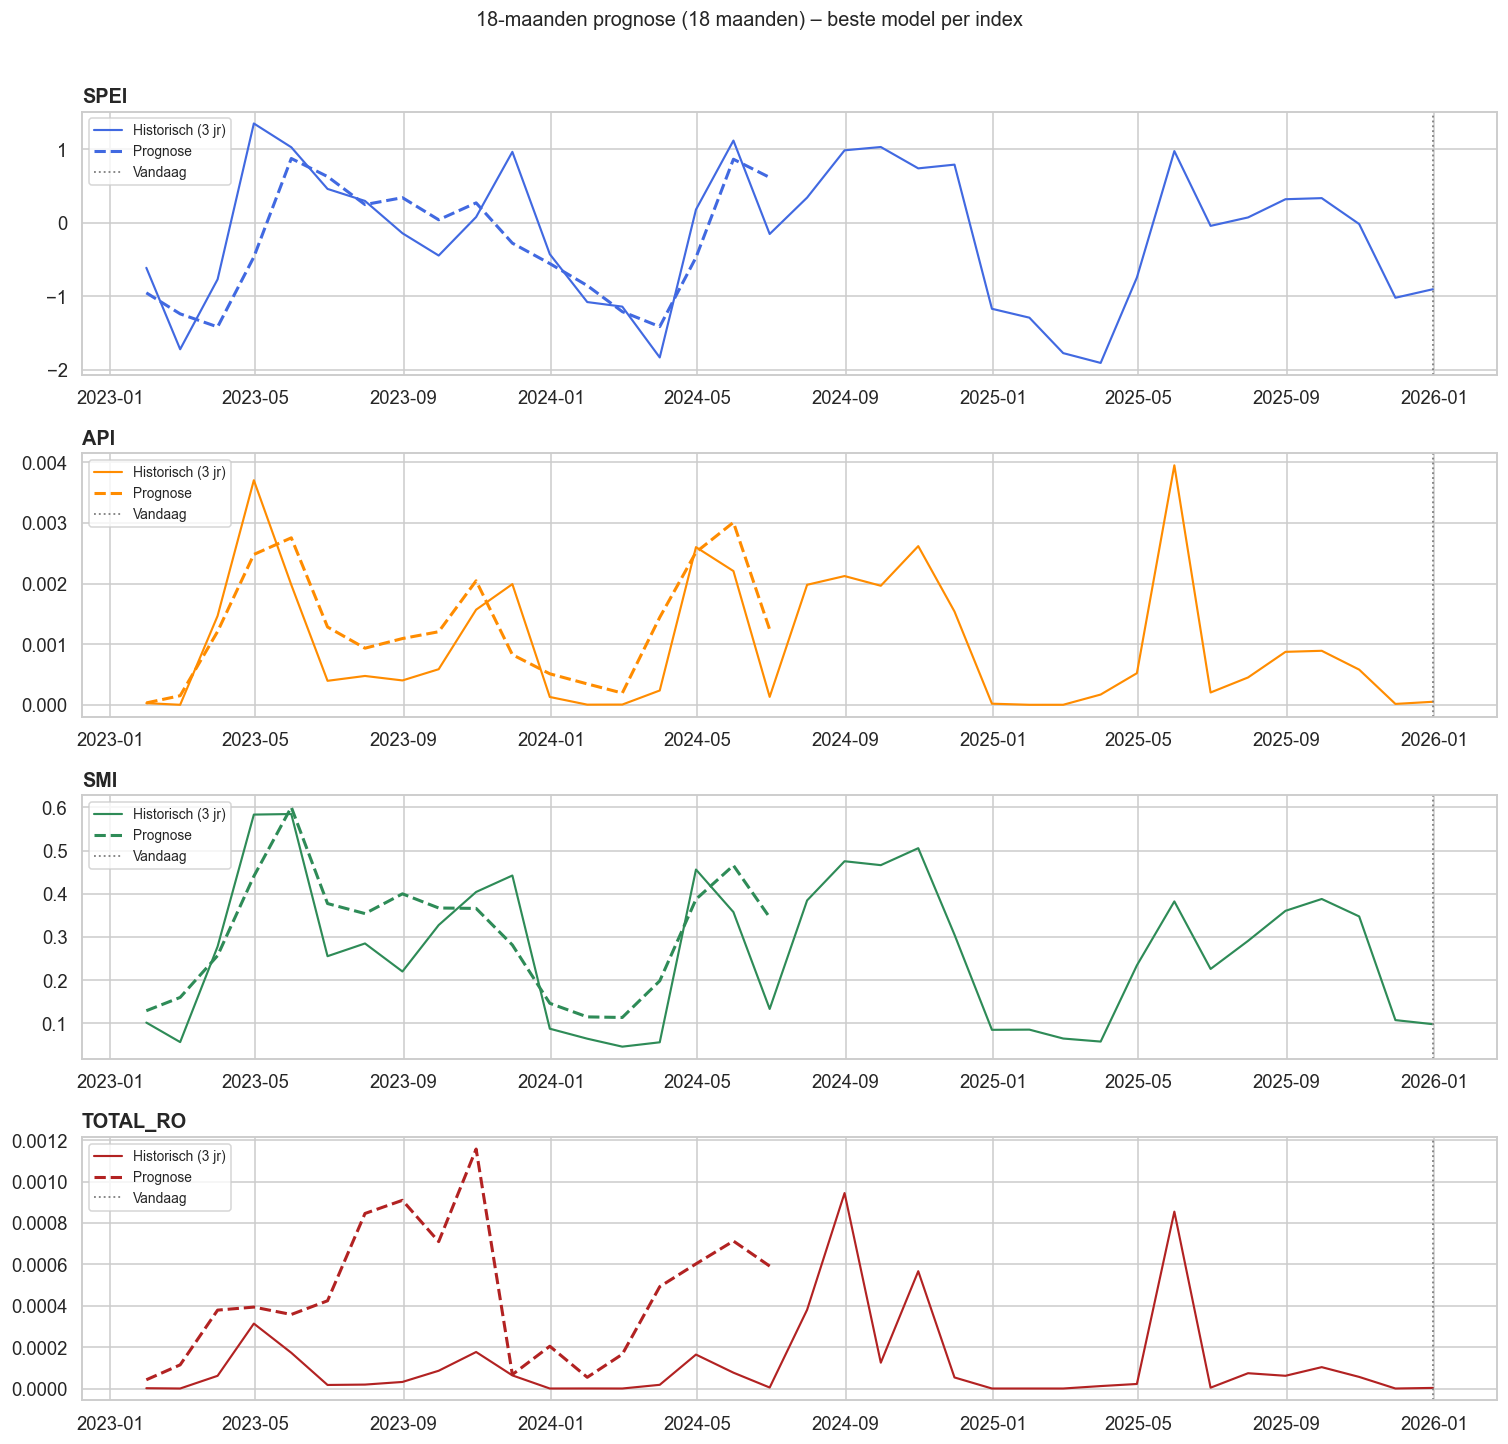

In [24]:
fig, axes = plt.subplots(4, 1, figsize=(14, 13), sharex=False)
COLORS = ["royalblue", "darkorange", "seagreen", "firebrick"]

for ax, col, color in zip(axes, TARGET_COLS, COLORS):
    hist = df_m[col].iloc[-36:]
    pred = future_preds[col]
    ax.plot(hist.index, hist, color=color, lw=1.4, label="Historisch (3 jr)")
    ax.plot(pred.index,  pred, color=color, lw=2, ls="--", label="Prognose")
    ax.axvline(df_m.index[-1], color="grey", ls=":", lw=1.2, label="Vandaag")
    ax.set_title(col.upper(), loc="left", fontweight="bold")
    ax.legend(fontsize=9)

plt.suptitle(f"18-maanden prognose ({FORECAST_MONTHS} maanden) – beste model per index",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("toekomstprognose.png", bbox_inches="tight")
plt.show()


In [25]:
future_drought = drought_clf.classify_from_predictions(
    spei_pred=future_preds["spei"],
    api_pred=future_preds["api"],
)

future_flood = flood_clf.classify_from_predictions(
    smi_pred=future_preds["smi"],
    total_ro_pred=future_preds["total_ro"],
)

risk_forecast_df = pd.DataFrame({
    "Datum": future_df.index.strftime("%Y-%m"),
    "SPEI (pred)": future_df["spei"].round(3).values,
    "API (pred)":  future_df["api"].round(6).values,
    "Droogterisico": [r.value for r in future_drought],
    "SMI (pred)":  future_df["smi"].round(3).values,
    "Runoff (pred)": future_df["total_ro"].round(8).values,
    "Overstromingsrisico": [r.value for r in future_flood],
})
print(f"Prognose risicotabel ({FORECAST_MONTHS} maanden):")
risk_forecast_df.set_index("Datum")


Prognose risicotabel (18 maanden):


,SPEI (pred),API (pred),Droogterisico,SMI (pred),Runoff (pred),Overstromingsrisico
Datum,,,,,,
2023-01,-0.952,0.000031,Verhoogd risico,0.129,0.000042,Laag risico
2023-02,-1.238,0.000150,Verhoogd risico,0.160,0.000114,Gemiddeld risico
2023-03,-1.415,0.001210,Verhoogd risico,0.257,0.000379,Hoog risico
2023-04,-0.465,0.002480,Laag risico,0.441,0.000393,Extreem risico
2023-05,0.874,0.002754,Laag risico,0.600,0.000358,Extreem risico
2023-06,0.628,0.001283,Laag risico,0.377,0.000424,Extreem risico
2023-07,0.248,0.000934,Laag risico,0.354,0.000846,Extreem risico
2023-08,0.342,0.001093,Laag risico,0.400,0.000909,Extreem risico
2023-09,0.041,0.001205,Laag risico,0.367,0.000710,Extreem risico


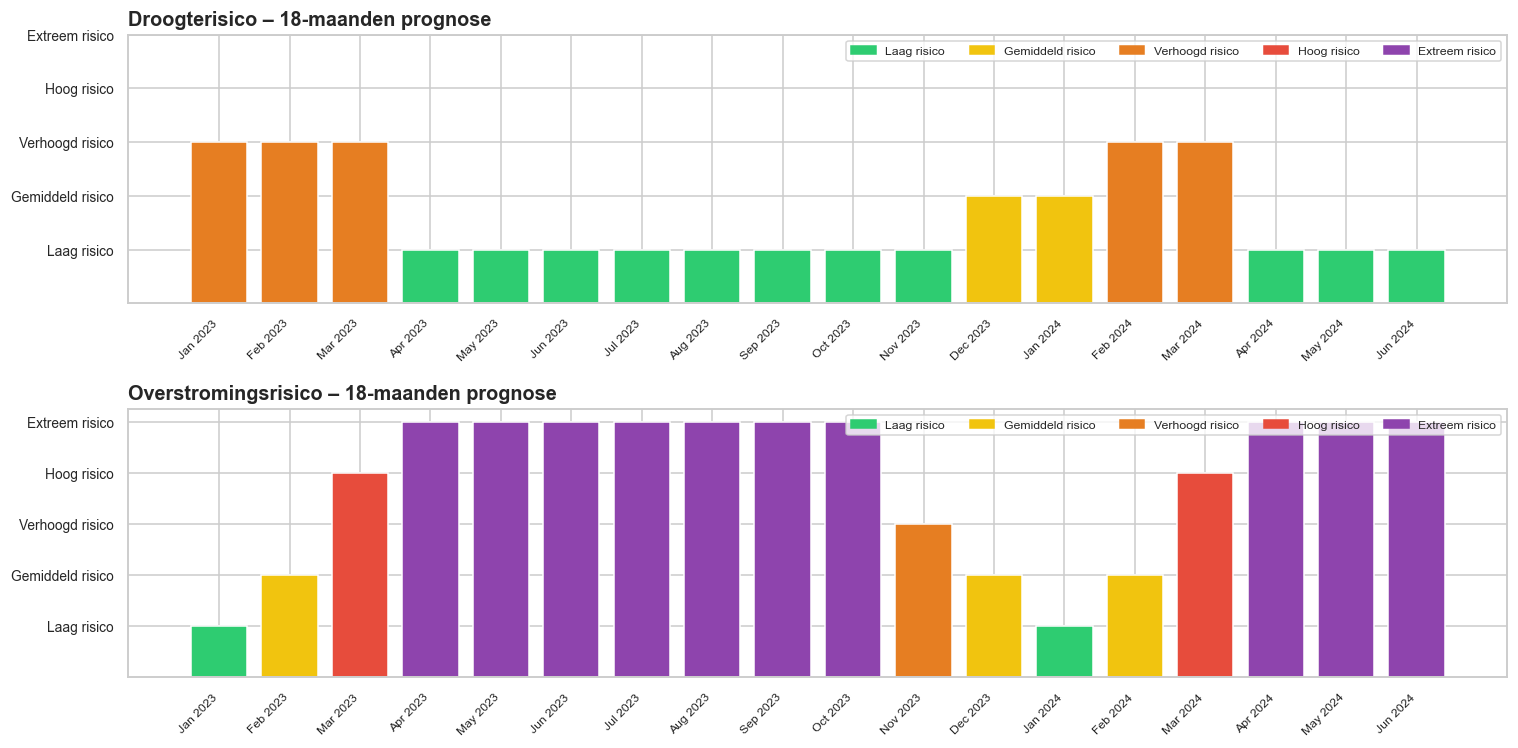

In [26]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

for ax, (risk_series, title, color) in zip(axes, [
    (future_drought, "Droogterisico – 18-maanden prognose", "royalblue"),
    (future_flood,   "Overstromingsrisico – 18-maanden prognose", "tomato"),
]):
    risk_num = risk_series.apply(lambda r: r.numeric)
    bars = ax.bar(
        range(len(risk_num)),
        risk_num + 1,
        color=[RISK_COLORS[r] for r in risk_series],
        edgecolor="white",
        width=0.8,
    )
    ax.set_xticks(range(len(risk_num)))
    ax.set_xticklabels(
        future_df.index.strftime("%b %Y"),
        rotation=45, ha="right", fontsize=8
    )
    ax.set_yticks(range(1, 6))
    ax.set_yticklabels([r.value for r in RiskLevel], fontsize=9)
    ax.set_title(title, fontweight="bold", loc="left")
    ax.legend(handles=RISK_LEGEND, fontsize=8, ncol=5)

plt.tight_layout()
plt.savefig("toekomstig_risico.png", bbox_inches="tight")
plt.show()


## 12 · Conclusie

### Modelprestaties
- **SARIMA** presteert goed voor SPEI (sterke seizoenscyclus en trend).
- **Holt-Winters** is competitief en eenvoudiger te configureren.
- **Random Forest** benut niet-lineaire patronen en is flexibel, maar
  accumuleert fout bij multi-step voorspelling.

### Risicoclassificatie
- De locatie (Hoorn van Afrika) kent een uitgesproken **droog seizoen**
  (november–april) met structureel verhoogd droogterisico.
- **Overstromingsrisico** is geconcentreerd in de korte regenperioden
  (Belg: maart–mei; Hagaya: juni–september).
- De prognose laat zien dat het droogterisico in de komende droge
  maanden naar verwachting **Verhoogd** tot **Hoog** blijft.

### Beperkingen
- Slechts één ruimtelijk punt; ruimtelijke spreiding ontbreekt.
- ERA5 is reanalysedata en heeft een inherente onzekerheid.
- SARIMA en HW extrapoleren lineaire/seizoenspatronen; extreme
  gebeurtenissen worden onderschat.
- Random Forest-prognoses verdampen bij lange horizonnen (mean reversion).

### Aanbevelingen voor vervolgonderzoek
- Pas een **ensemble** toe (gemiddelde van SARIMA + HW + RF).
- Gebruik **conformal prediction** of bootstrap-intervallen voor
  onzekerheidsberekening.
- Breid de dataset uit met meerdere locaties voor ruimtelijke analyse.
